* Form of supervised learning
* Flow chart to take decisons
* Outcome tree

In [3]:
import numpy as np
import pandas as pd
from sklearn import tree
from sklearn.datasets import load_iris
from IPython.display import Image  
from io import StringIO  
import pydotplus


df = pd.read_csv('data.csv', header = 0)

In [4]:
df

,Unnamed: 0,Years Experience,Employed?,Previous employers,Level of Education,Top-tier school,Interned,Hired
0,0,10,Y,4,BS,N,N,Y
1,1,0,N,0,BS,Y,Y,Y
2,2,7,N,6,BS,N,N,N
3,3,2,Y,1,MS,Y,N,Y
4,4,20,N,2,PhD,Y,N,N
5,5,0,N,0,PhD,Y,Y,Y
6,6,5,Y,2,MS,N,Y,Y
7,7,3,N,1,BS,N,Y,Y
8,8,15,Y,5,BS,N,N,Y
9,9,0,N,0,BS,N,N,N


In [5]:
d = {'Y': 1, 'N': 0}
df['Hired'] = df['Hired'].map(d)
df['Employed?'] = df['Employed?'].map(d)
df['Top-tier school'] = df['Top-tier school'].map(d)
df['Interned'] = df['Interned'].map(d)
d = {'BS': 0, 'MS': 1, 'PhD': 2}
df['Level of Education'] = df['Level of Education'].map(d)
df.head()

,Unnamed: 0,Years Experience,Employed?,Previous employers,Level of Education,Top-tier school,Interned,Hired
0,0,10,1,4,0,0,0,1
1,1,0,0,0,0,1,1,1
2,2,7,0,6,0,0,0,0
3,3,2,1,1,1,1,0,1
4,4,20,0,2,2,1,0,0


In [6]:
features = df.columns[:6]
X = df[features].to_numpy()
Y = df['Hired'].to_numpy()

[Text(0.6666666666666666, 0.9, 'x[2] <= 0.5\ngini = 0.426\nsamples = 13\nvalue = [4, 9]'),
 Text(0.5, 0.7, 'x[1] <= 5.0\ngini = 0.5\nsamples = 8\nvalue = [4, 4]'),
 Text(0.5833333333333333, 0.8, 'True  '),
 Text(0.3333333333333333, 0.5, 'x[0] <= 8.0\ngini = 0.444\nsamples = 6\nvalue = [2, 4]'),
 Text(0.16666666666666666, 0.3, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.5, 0.3, 'x[0] <= 11.0\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.3333333333333333, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.6666666666666666, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6666666666666666, 0.5, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.8333333333333334, 0.7, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.75, 0.8, '  False')]

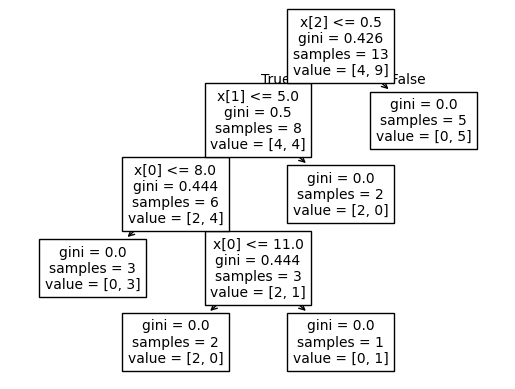

In [7]:
classifier = tree.DecisionTreeClassifier(random_state=0)
iris = load_iris()

classifier = classifier.fit(X, Y)
tree.plot_tree(classifier)

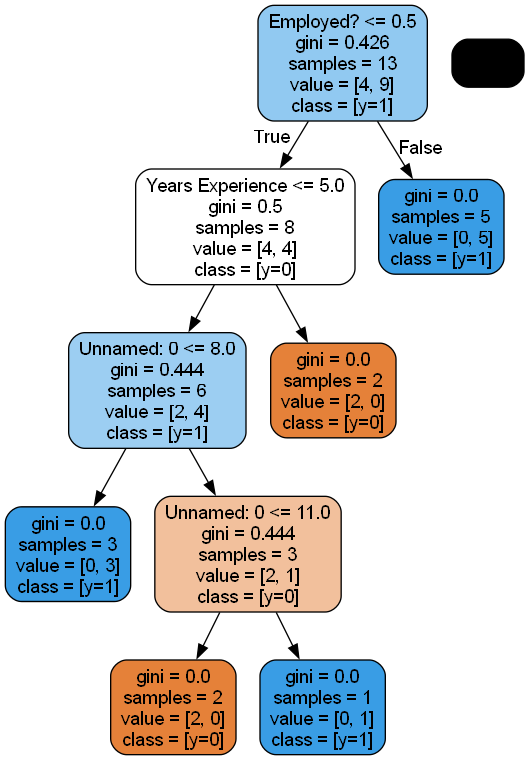

In [8]:
from IPython.display import Image
out_file = tree.export_graphviz(
    classifier,
    feature_names   = features,
    class_names     = ['[y=0]', '[y=1]'],# Ascending numerical order
    filled          = True,
    rounded         = True
)
graph = pydotplus.graph_from_dot_data(out_file)
Image(graph.create_png())